# Classification Masks Test and Visualization

This notebook loads classification data from a JSON file and visualizes the segmentation masks associated with each annotation. It compares:
- **Composite Masks**: Combined masks from all brush modifications and SAM interactions
- **SAM Masks**: The latest segmentation mask generated by SAM (Segment Anything Model)

## Purpose
- Verify that masks are being correctly saved and encoded
- Inspect the relationship between SAM-generated masks and brush-modified composite masks
- Validate mask dimensions and decoding process

In [ ]:
# Import required libraries for data handling, visualization, and mask decoding
import json  # for loading JSON classification data
from MaskDecoder import MaskDecoder  # custom decoder for RLE-encoded masks
import matplotlib.pyplot as plt  # for creating plots and figures
from matplotlib.pyplot import colormaps  # for accessing colormap functions
import matplotlib.patches as mpatches  # for creating custom legend patches
import numpy as np  # for numerical operations and array handling

## Load Test Classification Data

The test classification file contains exported annotations from a Caesar reduction task. Each annotation includes optional mask data:
- `annotationId`: Unique identifier for the annotation (e.g., "-1" for whole image, or rect coordinates)
- `latestSamMask`: The SAM segmentation mask (RLE-encoded)
- `compositeMask`: The composite mask after all brush modifications (RLE-encoded)

Both mask formats include width, height, RLE data, and encoding metadata.

In [13]:
TEST_CLASSIFICATION_PATH = 'test_classification.json'

with open(TEST_CLASSIFICATION_PATH, 'r') as classification_file:
    data = json.load(classification_file)

## Visualize Masks with Inset Zoom

For each annotation that has mask data, we create a visualization showing:
- The full image with overlay masks at different opacities
  - **Composite Mask** (gray, alpha=0.5): Shows all brush modifications combined
  - **SAM Mask** (blue, alpha=0.6): Shows the latest SAM segmentation
- An **inset axes** that zooms into the region containing the mask, positioned intelligently to avoid overlapping the masked data itself

The inset is automatically positioned in the opposite quadrant from the masked region, ensuring clear visibility without obstruction.

/var/folders/ff/6x49lsb142z6xcfbp_382_zxsrvmj6/T/ipykernel_94869/4111810976.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


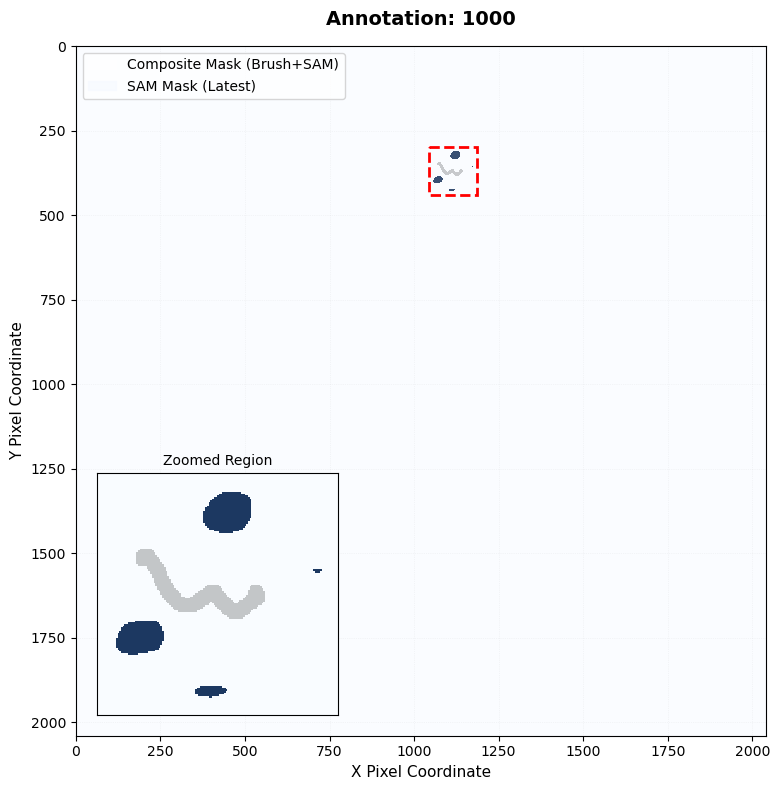

✓ Annotation 1000:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



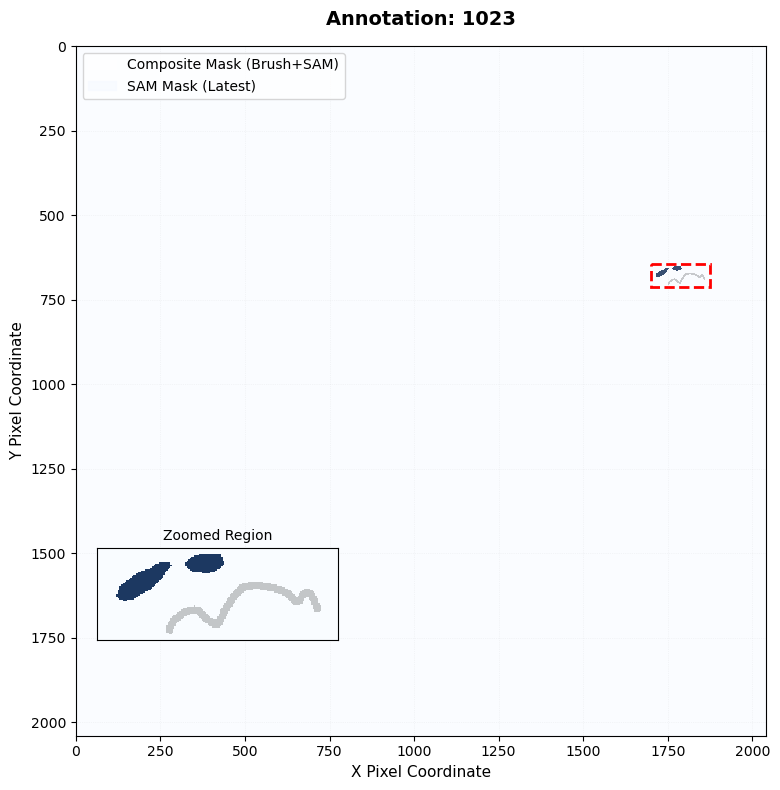

✓ Annotation 1023:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



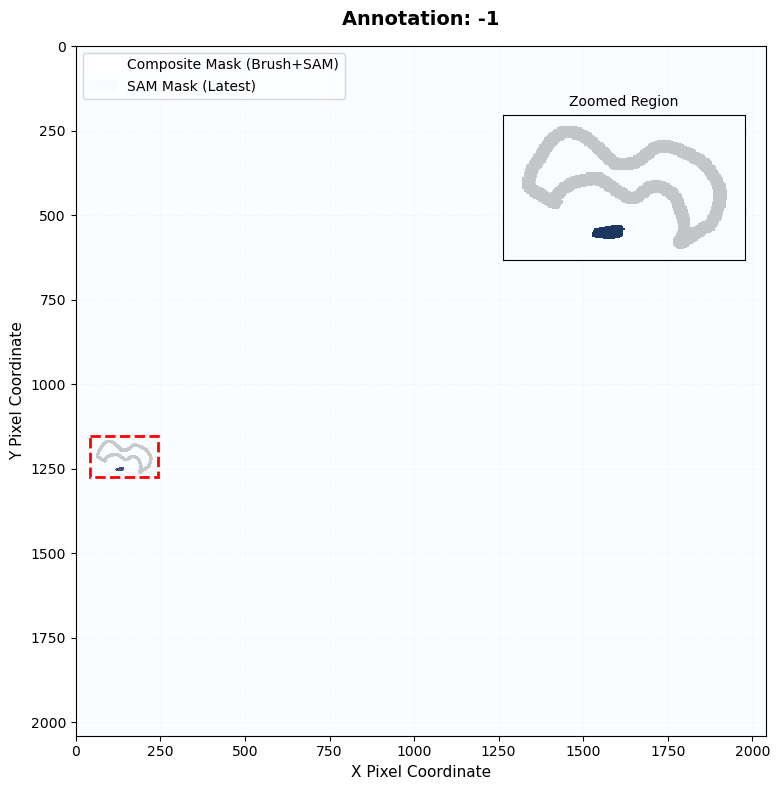

✓ Annotation -1:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



In [ ]:
# Helper function to get the bounding box of non-zero pixels in a mask

def get_mask_bounds(mask_array):
    """
    Find the bounding box containing all non-zero pixels in a mask.
    Returns (y_min, y_max, x_min, x_max) or None if mask is empty.
    """
    non_zero = np.nonzero(mask_array)
    if len(non_zero[0]) == 0:
        return None
    y_min, y_max = non_zero[0].min(), non_zero[0].max()
    x_min, x_max = non_zero[1].min(), non_zero[1].max()
    return (y_min, y_max, x_min, x_max)


def get_non_overlapping_inset_location(image_height, image_width, masked_y_min, masked_y_max, masked_x_min, masked_x_max):
    """
    Determine the best location for inset axes to avoid overlapping the masked region.
    Returns inset location string ('upper left', 'upper right', 'lower left', or 'lower right').
    """
    # Calculate the center of the masked region
    masked_y_center = (masked_y_min + masked_y_max) / 2
    masked_x_center = (masked_x_min + masked_x_max) / 2
    
    # Determine which quadrant the mask occupies and place inset in opposite quadrant
    if masked_y_center < image_height / 2:
        # Mask is in upper half, place inset in lower half
        if masked_x_center < image_width / 2:
            # Mask is upper-left, place inset in lower-right
            return 'lower right'
        else:
            # Mask is upper-right, place inset in lower-left
            return 'lower left'
    else:
        # Mask is in lower half, place inset in upper half
        if masked_x_center < image_width / 2:
            # Mask is lower-left, place inset in upper-right
            return 'upper right'
        else:
            # Mask is lower-right, place inset in upper-left
            return 'upper left'


# Iterate through all annotations in the first task
for annotation_value in data["annotations"][0]["value"]:
    # Only visualize annotations that have mask data
    if "latestSamMask" in annotation_value or "compositeMask" in annotation_value:
        annotation_id = annotation_value["annotationId"]
        
        # Create figure with larger size for better visibility
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(1, 1, 1)
        
        # Improved title showing annotation details
        ax.set_title(f"Annotation: {annotation_id}", fontsize=14, fontweight='bold', pad=15)
        
        # Initialize bounds tracking for inset axes
        all_bounds = []
        
        # Decode and display composite mask if available
        sam_mask_data = annotation_value.get("latestSamMask")
        composite_mask_data = annotation_value.get("compositeMask")
        
        if composite_mask_data:
            mask_decoder = MaskDecoder(
                width=composite_mask_data["width"],
                height=composite_mask_data["height"]
            )
            composite_array = mask_decoder.decode(
                composite_mask_data["rle"],
                encoding=composite_mask_data.get("encoding", "gzip-base64")
            )
            ax.imshow(
                composite_array,
                cmap='Greys',
                alpha=0.5,
                label='Composite Mask (Brush+SAM)',
                interpolation='nearest'
            )
            bounds = get_mask_bounds(composite_array)
            if bounds:
                all_bounds.append(bounds)
        
        # Decode and display SAM mask if available
        if sam_mask_data:
            mask_decoder = MaskDecoder(
                width=sam_mask_data["width"],
                height=sam_mask_data["height"]
            )
            sam_array = mask_decoder.decode(
                sam_mask_data["rle"],
                encoding=sam_mask_data.get("encoding", "gzip-base64")
            )
            ax.imshow(
                sam_array,
                cmap='Blues',  # Different color to distinguish from composite
                alpha=0.6,
                label='SAM Mask (Latest)',
                interpolation='nearest'
            )
            bounds = get_mask_bounds(sam_array)
            if bounds:
                all_bounds.append(bounds)
        
        # Compute combined bounding box from all masks
        if all_bounds:
            all_y_mins = [b[0] for b in all_bounds]
            all_y_maxs = [b[1] for b in all_bounds]
            all_x_mins = [b[2] for b in all_bounds]
            all_x_maxs = [b[3] for b in all_bounds]
            
            combined_y_min = min(all_y_mins)
            combined_y_max = max(all_y_maxs)
            combined_x_min = min(all_x_mins)
            combined_x_max = max(all_x_maxs)
            
            # Add padding around the masked region (10% on each side)
            y_padding = int(0.1 * (combined_y_max - combined_y_min))
            x_padding = int(0.1 * (combined_x_max - combined_x_min))
            
            inset_y_min = max(0, combined_y_min - y_padding)
            inset_y_max = min(composite_array.shape[0] if composite_mask_data else sam_array.shape[0], combined_y_max + y_padding)
            inset_x_min = max(0, combined_x_min - x_padding)
            inset_x_max = min(composite_array.shape[1] if composite_mask_data else sam_array.shape[1], combined_x_max + x_padding)
            
            # Determine optimal inset location to avoid overlapping the masked region
            image_height = composite_array.shape[0] if composite_mask_data else sam_array.shape[0]
            image_width = composite_array.shape[1] if composite_mask_data else sam_array.shape[1]
            inset_location = get_non_overlapping_inset_location(
                image_height, image_width,
                inset_y_min, inset_y_max, inset_x_min, inset_x_max
            )
            
            # Create inset axes in optimal location showing zoomed region
            from mpl_toolkits.axes_grid1.inset_locator import inset_axes
            axins = inset_axes(ax, width="35%", height="35%", loc=inset_location, borderpad=1.5)
            
            # Redraw masks in inset with higher opacity for clarity
            if composite_mask_data:
                axins.imshow(
                    composite_array[inset_y_min:inset_y_max, inset_x_min:inset_x_max],
                    cmap='Greys',
                    alpha=0.7,
                    interpolation='nearest',
                    label='Composite Mask (Zoomed)'
                )
            if sam_mask_data:
                axins.imshow(
                    sam_array[inset_y_min:inset_y_max, inset_x_min:inset_x_max],
                    cmap='Blues',
                    alpha=0.7,
                    interpolation='nearest',
                    label='SAM Mask (Zoomed)'
                )
            
            # Mark the inset region on the main plot with a rectangle
            from matplotlib.patches import Rectangle
            rect = Rectangle(
                (inset_x_min, inset_y_min),
                inset_x_max - inset_x_min,
                inset_y_max - inset_y_min,
                linewidth=2,
                edgecolor='red',
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(rect)
            
            # Clean inset axes
            axins.set_xticks([])
            axins.set_yticks([])
            axins.set_title('Zoomed Region', fontsize=10)
        
        # Add axis labels and improve appearance
        ax.set_xlabel('X Pixel Coordinate', fontsize=11)
        ax.set_ylabel('Y Pixel Coordinate', fontsize=11)
        ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
        
        # Add legend
        if composite_mask_data or sam_mask_data:
            patches = [mpatches.Patch(color=colormaps['Greys'](1), alpha=0.7, label='Composite Mask (Brush+SAM)'), mpatches.Patch(color=colormaps['Blues'](1), alpha=0.7, label='SAM Mask (Latest)')]
            ax.legend(handles=patches, loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Print mask information to console
        print(f"✓ Annotation {annotation_id}:")
        if composite_mask_data:
            print(f"  - Composite: {composite_mask_data['width']}×{composite_mask_data['height']} ({composite_mask_data.get('encoding', 'unknown')})")
        if sam_mask_data:
            print(f"  - SAM: {sam_mask_data['width']}×{sam_mask_data['height']} ({sam_mask_data.get('encoding', 'unknown')})")
        print()

## Analysis Notes

### What Each Visualization Shows:
- **Main axes**: Full image with overlaid segmentation masks
  - **Gray overlay** = Composite mask (all modifications combined)
  - **Blue overlay** = SAM mask (latest segmentation)
- **Red dashed rectangle** = Boundary of the zoomed region shown in inset
- **Inset axes** (positioned intelligently): High-opacity zoomed view of the masked region for detailed inspection
  - Positioned in the opposite quadrant from the masked region to avoid overlapping the data
  - If mask is in upper-left, inset appears in lower-right (and vice versa)

### Key Validation Points:
- Mask dimensions should match the image dimensions
- Composite masks should contain or equal the SAM masks (since composites include SAM + brush modifications)
- The zoomed inset should clearly show mask boundaries and any brush stroke details
- Encoding format (typically "gzip-base64") should match between saved and loaded masks
- Inset position adapts to ensure it doesn't obscure the region being examined